In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import matplotlib as plt
import numpy as np
from PIL import ImageFile
from PIL import Image

import os
import shutil
from pathlib import Path

from cleanvision import Imagelab

import re #regular expressions

import cairosvg


In [2]:
def show_images_side_by_side(image_paths, figsize=(15, 5)):
    """
    Displays a list of images side by side in a single row.
    Handles mislabeled extensions and corrupted files safely.
    """
    num_images = len(image_paths)
    if num_images == 0:
        print("No image paths provided.")
        return

    fig, axes = plt.subplots(1, num_images, figsize=figsize)
    
    if num_images == 1:
        axes = [axes]
        
    for i, path in enumerate(image_paths):
        if os.path.exists(path):
            try:
                # PIL ignores the file extension and reads the true internal format
                img = Image.open(path)
                axes[i].imshow(img)
                axes[i].set_title(os.path.basename(path))
            except Exception as e:
                # Catches "not a PNG file", corruption, or unreadable formats safely
                axes[i].text(0.5, 0.5, f"Invalid Image:\n{os.path.basename(path)}", 
                             ha='center', va='center', color='orange', wrap=True)
                print(f"Warning: Skipping {os.path.basename(path)} due to error: {e}")
        else:
            axes[i].text(0.5, 0.5, f"File Not Found:\n{os.path.basename(path)}", 
                         ha='center', va='center', color='red', wrap=True)
            
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Investigating file sizes

In [2]:
file_size_df = pd.DataFrame(columns = ["Pokemon Name", "# Files"])
for dir in os.listdir("/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1"):
    if os.path.isdir(f"/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/{dir}"):
        file_size_df.loc[len(file_size_df)] = [dir, len(os.listdir(f"/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.0/{dir}"))]
print(len(os.listdir(f"/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1")))


151


In [ ]:
# pd.set_option('display.max_columns', 5)
pd.set_option('display.max_rows', 160)

file_size_df.sort_values(by = "# Files")
# file_size_df.head(160)

# pd.set_option('display.max_rows', 10)



In [ ]:
sns.histplot(data = file_size_df,
              x = '# Files',
              stat = 'count',
              bins = 10)

plt.show()

Checking For Dupes

In [9]:
# Specify the path to the folder containing your image files
imagelab = Imagelab(data_path="/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra")

custom_params = {
    "exact_duplicates": {}, # Catches exact mathematical clones
    "near_duplicates": {
        "threshold": 0.1
    }
}


imagelab.find_issues(issue_types = custom_params)



Reading images from /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra
Checking for exact_duplicates, near_duplicates images ...


Computing hashes:   0%|          | 0/407 [00:00<?, ?it/s]

Issue checks completed. 203 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().


Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | exact_duplicates |          158 |
|  1 | near_duplicates  |           45 | 

----------------- exact_duplicates images ------------------

Number of examples with this issue: 158
Examples representing most severe instances of this issue:

Set: 0


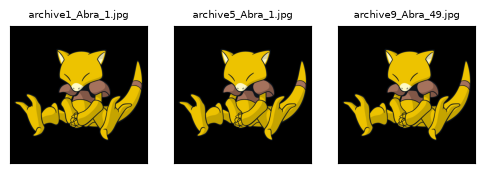

Set: 1


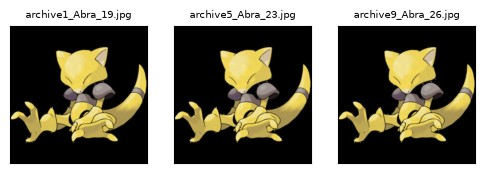

Set: 2


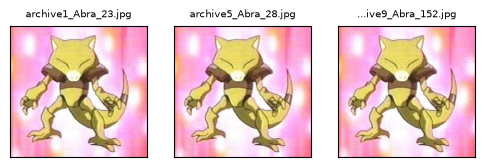

Set: 3


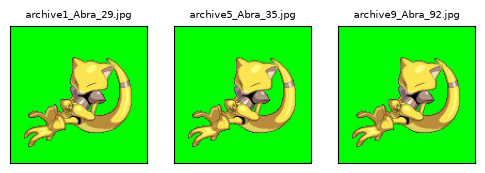

------------------ near_duplicates images ------------------

Number of examples with this issue: 45
Examples representing most severe instances of this issue:

Set: 0


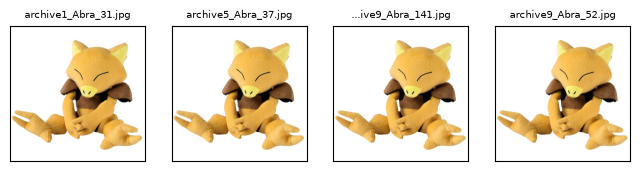

Set: 1


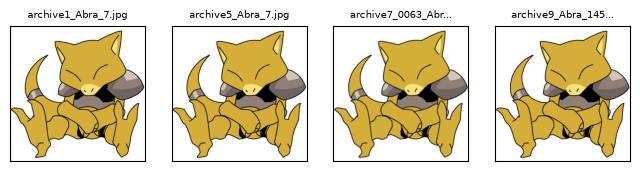

Set: 2


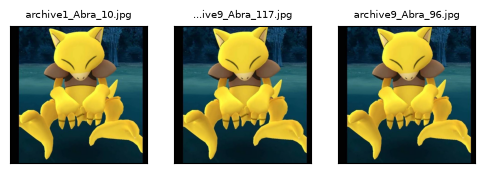

Set: 3


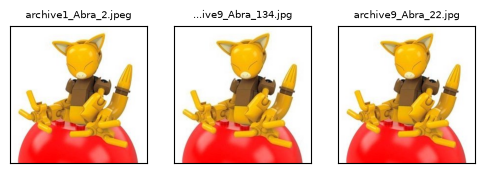

In [ ]:
imagelab.report()


In [12]:
all_dupe_sets = imagelab.info['exact_duplicates']['sets'] + imagelab.info['near_duplicates']['sets']

print(all_dupe_sets)

[['/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive1_Abra_1.jpg', '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive5_Abra_1.jpg', '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive9_Abra_49.jpg'], ['/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive1_Abra_10.jpg', '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive9_Abra_96.jpg'], ['/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive1_Abra_11.jpg', '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive9_Abra_68.jpg'], ['/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive1_Abra_12.jpg', '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra/archive9_Abra_19.jpg'], ['/home/dght

In [ ]:
# shutil.rmtree("/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/Corrupted_Images")
# shutil.copytree("/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.0","/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1")

'/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1'

In [20]:
base_path = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1"
quarantine_path = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/Corrupted_Images"

os.makedirs(quarantine_path, exist_ok=True)
corrupted_count = 0
# 2. Pre-screen the dataset
for dir_name in os.listdir(base_path):
    class_path = os.path.join(base_path, dir_name)
    if not os.path.isdir(class_path) or dir_name == "Corrupted_Images":
        continue
        
    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)
        
        try:
            # Check the header
            with Image.open(file_path) as img:
                img.verify() 
            
            # verify() requires reopening the image to test pixel data loading
            with Image.open(file_path) as img:
                img.load() 
            # load() loads the image's pixels
        except Exception as e:
            print(f"Corrupted image found in {dir_name}: {file_name} ({e})")
            
            # Move the file to the quarantine folder so it isn't lost, but is out of the way
            dest_path = os.path.join(quarantine_path, f"{dir_name}_{file_name}")
            shutil.move(file_path, dest_path)
            corrupted_count += 1

print(f"\nScan complete. Moved {corrupted_count} corrupted images to: {quarantine_path}\n")

Corrupted image found in Nidoqueen: archive5_Nidoqueen_28.svg (cannot identify image file '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Nidoqueen/archive5_Nidoqueen_28.svg')
Corrupted image found in Kingler: archive5_Kingler_36.svg (cannot identify image file '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Kingler/archive5_Kingler_36.svg')
Corrupted image found in Dewgong: archive1_Dewgong_26.svg (cannot identify image file '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Dewgong/archive1_Dewgong_26.svg')
Corrupted image found in Dewgong: archive5_Dewgong_34.svg (cannot identify image file '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Dewgong/archive5_Dewgong_34.svg')
Corrupted image found in Fearow: archive5_Fearow_86.svg (cannot identify image file '/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Fearow/archive5_Fearow_

In [ ]:
# #40 Files flagged, 1 was actually corrupted (Exegutor217) rest were svg files that need to be converted to png
# quarantine_path = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/Corrupted_Images"

# print("Starting SVG conversion...")

# for file_name in os.listdir(quarantine_path):
#     # Only process files that end with .svg (handling both upper and lower case)
#     if file_name.lower().endswith('.svg'):
#         svg_path = os.path.join(quarantine_path, file_name)
        
#         # Create a new filename replacing .svg with .png
#         png_name = file_name[:-4] + ".png"
#         png_path = os.path.join(quarantine_path, png_name)
        
#         try:
#             # Convert the vector graphic to a rasterized PNG
#             cairosvg.svg2png(url=svg_path, write_to=png_path)
#             print(f"Successfully converted: {file_name} -> {png_name}")
            
#             # Optional: Delete the original SVG after successful conversion
#             # os.remove(svg_path)
            
#         except Exception as e:
#             print(f"Failed to convert {file_name}: {e}")

# print("Conversion complete.")

Starting SVG conversion...
Successfully converted: Scyther_archive5_Scyther_67.svg -> Scyther_archive5_Scyther_67.png
Successfully converted: Machamp_archive5_Machamp_13.svg -> Machamp_archive5_Machamp_13.png
Successfully converted: Magneton_archive1_Magneton_40.svg -> Magneton_archive1_Magneton_40.png
Successfully converted: Graveler_archive1_Graveler_5.svg -> Graveler_archive1_Graveler_5.png
Successfully converted: Kabutops_archive5_Kabutops_59.svg -> Kabutops_archive5_Kabutops_59.png
Successfully converted: Tentacruel_archive1_Tentacruel_3.svg -> Tentacruel_archive1_Tentacruel_3.png
Successfully converted: Fearow_archive5_Fearow_86.svg -> Fearow_archive5_Fearow_86.png
Successfully converted: Golduck_archive5_Golduck_57.svg -> Golduck_archive5_Golduck_57.png
Successfully converted: Fearow_archive5_Fearow_13.svg -> Fearow_archive5_Fearow_13.png
Successfully converted: Exeggutor_archive5_Exeggutor_28.svg -> Exeggutor_archive5_Exeggutor_28.png
Successfully converted: Venomoth_archive1_V

In [ ]:
#Transport the converted pngs back into their classes:

base_path = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1"
quarantine_path = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/Corrupted_Images"

for img in os.listdir(quarantine_path):
  if '_' in img and img.endswith('.png'):
    class_name, original_name = img.split('_', 1)
    src_path = os.path.join(quarantine_path, img)
    
    # 2. Where is it going? (Back to MasterDataSet1.1/ClassName/OriginalName.png)
    dst_path = os.path.join(base_path, class_name, original_name)

    try:
      shutil.move(src_path, dst_path)
      print(f"Restored: {original_name} to {class_name}/")
    except FileNotFoundError:
      print(f"Error: The class folder for {class_name} does not exist.")


Restored: archive5_Nidoqueen_28.png to Nidoqueen/
Restored: archive5_Kabutops_59.png to Kabutops/
Restored: archive5_Zapdos_58.png to Zapdos/
Restored: archive5_Kingler_36.png to Kingler/
Restored: archive5_Exeggutor_12.png to Exeggutor/
Restored: archive5_Fearow_13.png to Fearow/
Restored: archive5_Caterpie_5.png to Caterpie/
Restored: archive5_Cloyster_28.png to Cloyster/
Restored: archive5_Omastar_21.png to Omastar/
Restored: archive5_Venomoth_33.png to Venomoth/
Restored: archive5_Hypno_59.png to Hypno/
Restored: archive1_Omastar_43.png to Omastar/
Restored: archive5_Omastar_57.png to Omastar/
Restored: archive5_Machamp_13.png to Machamp/
Restored: archive5_Exeggutor_28.png to Exeggutor/
Restored: archive1_Tentacruel_3.png to Tentacruel/
Restored: archive5_Dewgong_34.png to Dewgong/
Restored: archive1_Scyther_58.png to Scyther/
Restored: archive1_Venomoth_25.png to Venomoth/
Restored: archive5_Poliwag_7.png to Poliwag/
Restored: archive5_Electabuzz_30.png to Electabuzz/
Restored: a

In [ ]:
ImageFile.LOAD_TRUNCATED_IMAGES = True
custom_params = {
    "exact_duplicates": {}, # Catches exact mathematical clones
    "near_duplicates": {
        "threshold": 0.1
    }
}

base_path = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1"

clean_file_size_df = pd.DataFrame(columns = ["Pokemon Name", "Clean # Files"])

for dir in os.listdir(base_path):
    class_path = os.path.join(base_path, dir)
    if not os.path.isdir(class_path):
        continue
    print(f"Processing: {dir}...")
    imagelab = Imagelab(data_path = class_path)
    imagelab.find_issues(issue_types = custom_params)

    all_dupe_sets = imagelab.info.get('exact_duplicates', {}).get('sets', []) + imagelab.info.get('near_duplicates', {}).get('sets', [])

    remove_img = []
    for group in all_dupe_sets:
        # print(f"Group {index}:")
        # remove_img.append(all_dupe_sets[group][1:])
        remove_img.extend(group[1:])

    print(len(remove_img))
    clean_file_size_df.loc[len(clean_file_size_df)] = [dir, len(remove_img)]
print(len(clean_file_size_df))
# indice = 0
# for file_path in remove_img:
#     try:
#         os.remove(file_path)
#         print(f"Removed: {file_path}")
#     except FileNotFoundError:
#         print(f"Couldn't find {file_path} at index {indice}")
#     except Exception as e:
#         print(f"Error removing {file_path}: {e}")
#     indice += 1
        

Processing: Drowzee...
Reading images from /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee
Checking for exact_duplicates, near_duplicates images ...


Computing hashes:   0%|          | 0/496 [00:00<?, ?it/s]

Issue checks completed. 282 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
157
Processing: Mew...
Reading images from /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Mew
Checking for exact_duplicates, near_duplicates images ...


Computing hashes:   0%|          | 0/512 [00:00<?, ?it/s]

Issue checks completed. 347 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
209
Processing: Muk...
Reading images from /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Muk
Checking for exact_duplicates, near_duplicates images ...


...

Computing hashes:   0%|          | 0/1064 [00:00<?, ?it/s]

/home/dghtan/Projects/Pokemon-Image-Prediction/.venv/lib/python3.12/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/dghtan/Projects/Pokemon-Image-Prediction/.venv/lib/python3.12/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/dghtan/Projects/Pokemon-Image-Prediction/.venv/lib/python3.12/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Issue checks completed. 897 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
542
Processing: Weezing...
Reading images from /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Weezing
Checking for exact_duplicates, near_duplicates images ...


Computing hashes:   0%|          | 0/527 [00:00<?, ?it/s]

Issue checks completed. 323 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
181
151


In [ ]:
merged_df = pd.merge(file_size_df, clean_file_size_df, on='Pokemon Name')
merged_df["Unique Files"] = merged_df["# Files"] - merged_df["Clean # Files"]



In [34]:
pd.set_option('display.max_rows', 160)

merged_df.sort_values(by = "Unique Files")

# pd.set_option('display.max_rows', 10)


,Pokemon Name,# Files,Clean # Files,Unique Files
119,Nidoran-m,165,23,142
63,Nidoran-f,167,23,144
21,Persian,399,114,285
125,Seaking,453,160,293
34,Abra,407,112,295
51,Beedrill,434,135,299
112,Machoke,467,166,301
83,Graveler,474,173,301
1,Mew,512,209,303
90,Onix,414,111,303


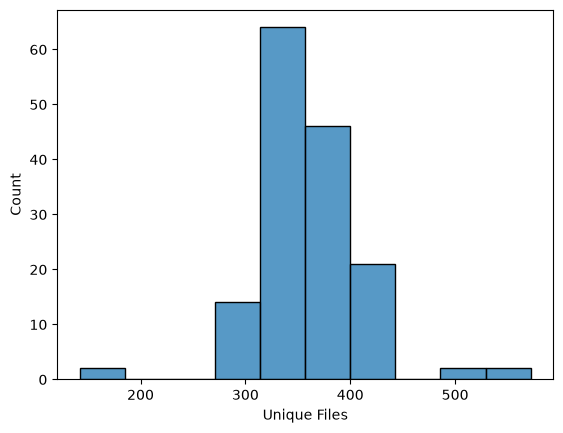

In [37]:
sns.histplot(data = merged_df,
              x = 'Unique Files',
              stat = 'count',
              bins = 10)

plt.show()

In [ ]:
# ImageFile.LOAD_TRUNCATED_IMAGES = True
# custom_params = {
#   "exact_duplicates": {}, # Catches exact mathematical clones
#   "near_duplicates": {
#       "threshold": 0.1
#   }
# }

# base_path = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1"

# #Number of files deleted in Clean # Files
# clean_file_size_df = pd.DataFrame(columns = ["Pokemon Name", "Clean # Files"])

# for dir in os.listdir(base_path):
#   class_path = os.path.join(base_path, dir)
#   if not os.path.isdir(class_path):
#       continue
#   print(f"Processing: {dir}...")
#   imagelab = Imagelab(data_path = class_path)
#   imagelab.find_issues(issue_types = custom_params)

#   all_dupe_sets = imagelab.info.get('exact_duplicates', {}).get('sets', []) + imagelab.info.get('near_duplicates', {}).get('sets', [])

#   remove_img = []
#   for group in all_dupe_sets:
#       # print(f"Group {index}:")
#       # remove_img.append(all_dupe_sets[group][1:])
#       remove_img.extend(group[1:])

#   print(len(remove_img))
#   clean_file_size_df.loc[len(clean_file_size_df)] = [dir, len(remove_img)]
#   indice = 0
#   for file_path in remove_img:
#     try:
#         os.remove(file_path)
#         print(f"Removed: {file_path}")
#     except FileNotFoundError:
#         print(f"Couldn't find {file_path} at index {indice}")
#     except Exception as e:
#         print(f"Error removing {file_path}: {e}")
#     indice += 1
# print("\nFinal Dataset Overview:")
# print(clean_file_size_df)
# print(f"Total classes processed: {len(clean_file_size_df)}")
        

Processing: Drowzee...
Reading images from /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee
Checking for exact_duplicates, near_duplicates images ...


Computing hashes:   0%|          | 0/496 [00:00<?, ?it/s]

Issue checks completed. 282 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
157
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee/archive9_Drowzee_202.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee/archive5_Drowzee_15.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee/archive9_Drowzee_18.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee/archive5_Drowzee_16.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee/archive9_Drowzee_145.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee/archive9_Drowzee_170.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Drowzee/archive9_Drowzee_102.jpg
Removed: /home/dghtan/P

Computing hashes:   0%|          | 0/512 [00:00<?, ?it/s]

Issue checks completed. 347 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
209
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Mew/archive5_Mew_1.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Mew/archive9_Mew_177.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Mew/archive9_Mew_1.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Mew/archive5_Mew_16.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Mew/archive9_Mew_145.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Mew/archive5_Mew_17.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Mew/archive9_Mew_25.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataS

...

Computing hashes:   0%|          | 0/1064 [00:00<?, ?it/s]

/home/dghtan/Projects/Pokemon-Image-Prediction/.venv/lib/python3.12/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/dghtan/Projects/Pokemon-Image-Prediction/.venv/lib/python3.12/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/dghtan/Projects/Pokemon-Image-Prediction/.venv/lib/python3.12/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Issue checks completed. 897 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
542
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Pikachu/archive9_Pikachu_401.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Pikachu/archive9_Pikachu_474.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Pikachu/archive5_Pikachu_56.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Pikachu/archive9_Pikachu_186.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Pikachu/archive9_Pikachu_400.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Pikachu/archive9_Pikachu_66.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Pikachu/archive9_Pikachu_493.png
Removed: /home/dghtan/

Computing hashes:   0%|          | 0/527 [00:00<?, ?it/s]

Issue checks completed. 323 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
181
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Weezing/archive5_Weezing_1.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Weezing/archive9_Weezing_212.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Weezing/archive5_Weezing_13.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Weezing/archive9_Weezing_228.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Weezing/archive9_Weezing_40.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Weezing/archive9_Weezing_205.jpg
Removed: /home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Weezing/archive9_Weezing_62.jpg
Removed: /home/dghtan/Pro

In [3]:
import cv2
from pathlib import Path
from collections import defaultdict

def scan_and_build_graph(directory_path, match_threshold=40, match_distance = 50):
    valid_exts = {'.jpg', '.jpeg', '.png'}
    img_paths = [str(p) for p in Path(directory_path).iterdir() if p.suffix.lower() in valid_exts]
    
    orb = cv2.ORB_create()
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    
    # Pre-compute descriptors
    descriptors = {}
    for path in img_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            _, des = orb.detectAndCompute(img, None)
            descriptors[path] = des

    # YOUR LOGIC: Every image gets its own set to track what it has been compared to/flagged with
    # defaultdict automatically creates an empty set if the key doesn't exist yet
    flagged_pairs = defaultdict(set) 

    # We still use the nested loop to move forward through the list
    for i in range(len(img_paths)):
        img1 = img_paths[i]
        des1 = descriptors.get(img1)
        
        for j in range(i + 1, len(img_paths)):
            img2 = img_paths[j]
            
            # YOUR SKIP LOGIC: If these specific two images have already been flagged together, skip
            if img2 in flagged_pairs[img1]:
                continue
                
            des2 = descriptors.get(img2)
            if des1 is None or des2 is None:
                continue
                
            # Perform the match
            matches = bf.match(des1, des2)
            good_matches = [m for m in matches if m.distance < match_distance]
            
            if len(good_matches) > match_threshold:
                # Store the match bidirectionally so neither compares to the other again!
                flagged_pairs[img1].add(img2)
                flagged_pairs[img2].add(img1)
                
    return flagged_pairs

# Run the function
# graph = scan_and_build_graph("path/to/pokemon/dataset/pikachu")

In [4]:
directory = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSet1.1/Abra"
#Default of 40 matches and 50 match distance
dupes_found =scan_and_build_graph(directory, 40, 40)



In [5]:
print(len(dupes_found))
print(type(dupes_found))

non_dupes = set()
for key in dupes_found:
    if not dupes_found[key]:
        # print(dupes_found[key])
        non_dupes.add(key)
for items in non_dupes:
    dupes_found.pop(items, None)

print(len(dupes_found))


305
<class 'collections.defaultdict'>
126


In [9]:
print(len(dupes_found))
# print(dupes_found[i][0])
# print(dupes_found[i][1])

def show_seq_img(start, iterations):
  key_list = list(dupes_found.keys())
  for i in range(iterations):
    # paths = [dupes_found[start+i][0], dupes_found[start+1][1]]
    
    cur_set = dupes_found[key_list[i+start]].copy()
    cur_set.add(key_list[i+start])

    paths = list(cur_set)
    show_images_side_by_side(paths)
    print(start+i)


126


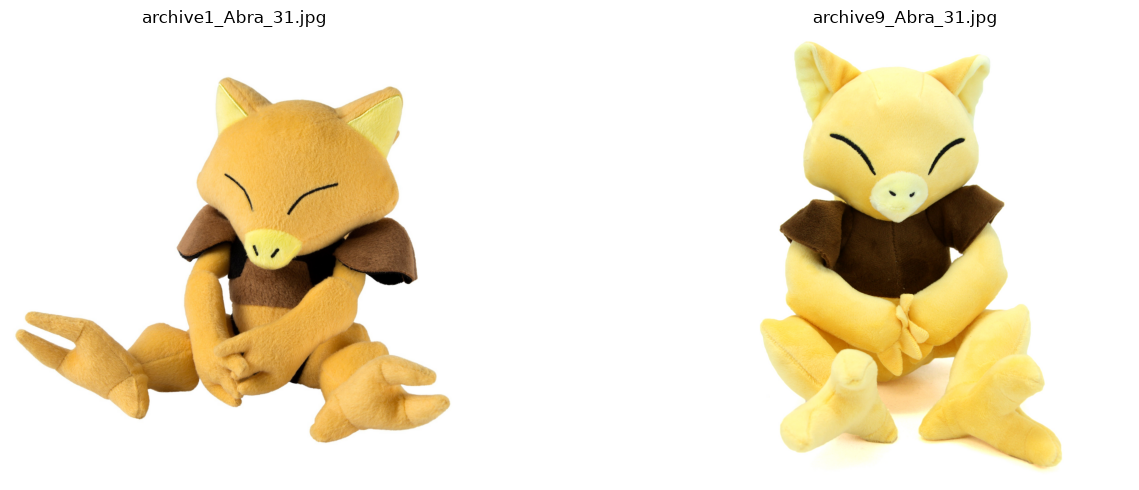

5


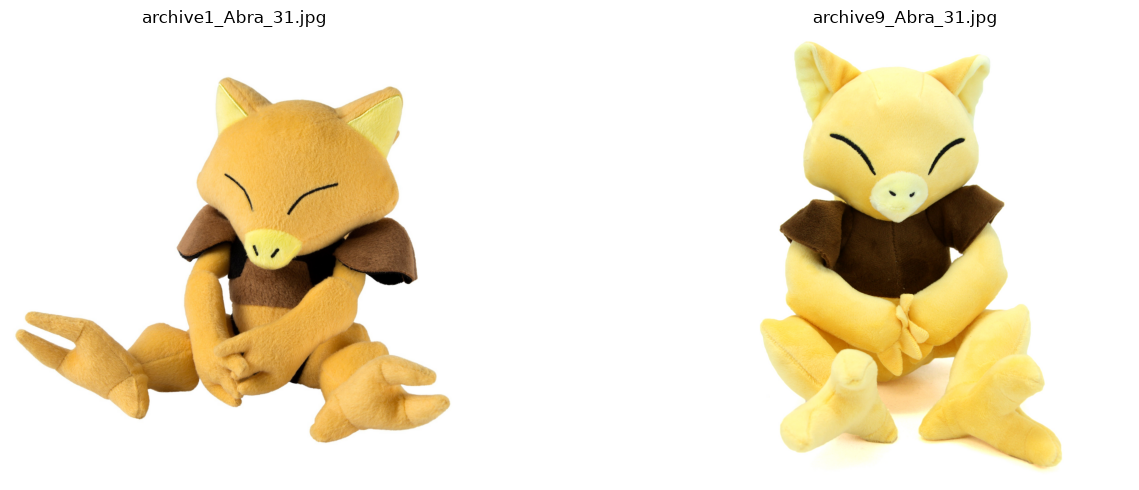

6


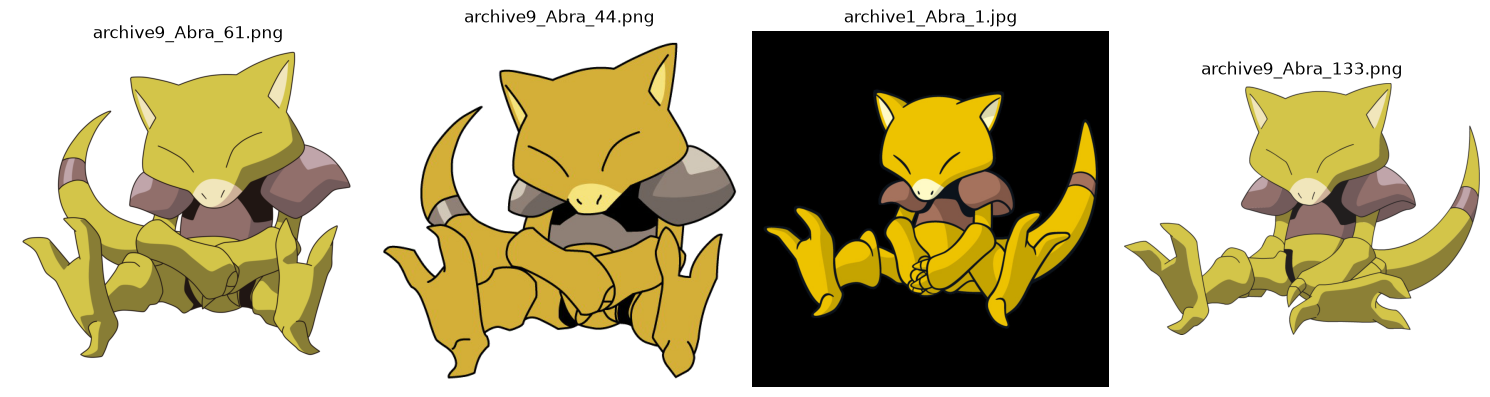

7


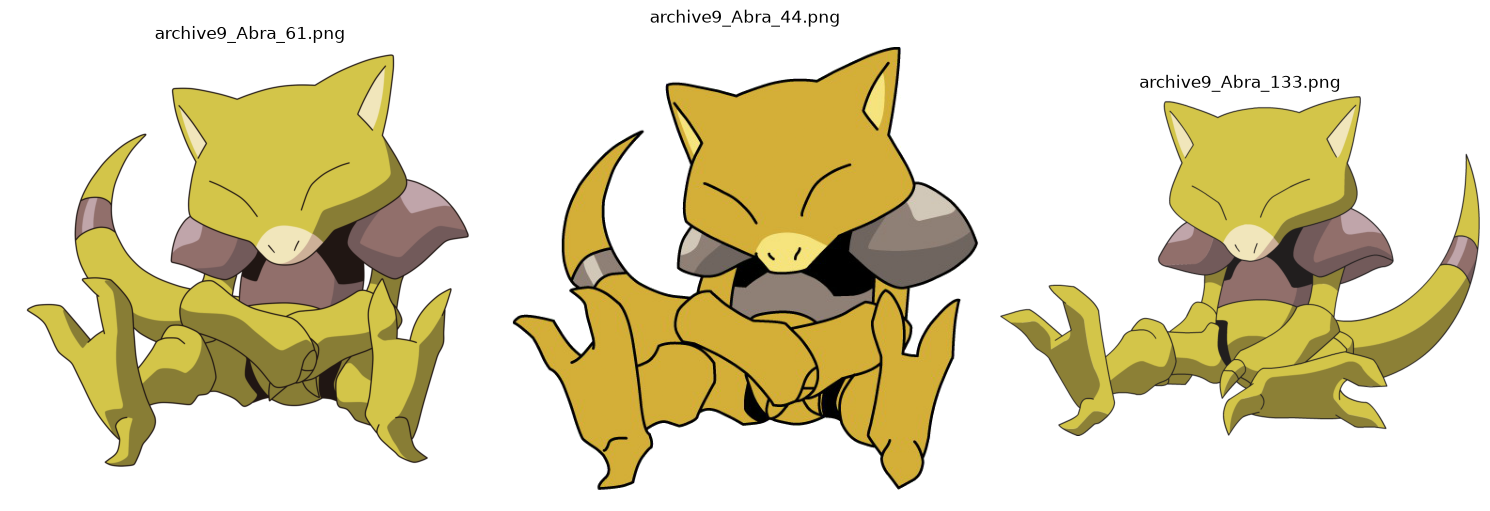

8


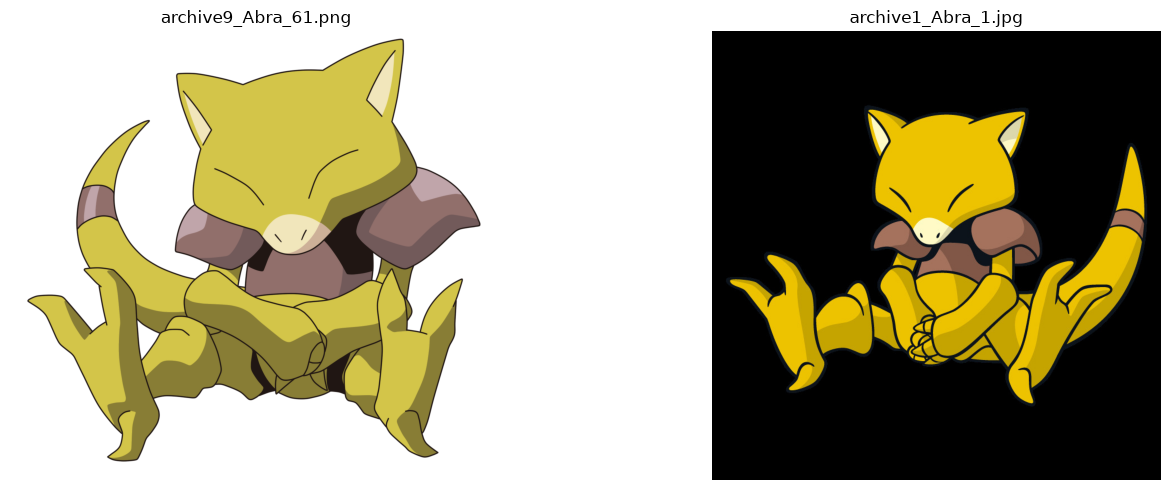

9


In [8]:
show_seq_img(5,5)